<a href="https://colab.research.google.com/github/alicjakorzanska/Interactive-Linguistic-Essay/blob/main/Interactive_Linguistic_Essay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Linguistics Essay - Alicja Korzańska

This essay investigates the usage of English in the article "Weizenbaum’s nightmares: how the inventor of the first chatbot turned against AI" by Ben Tarnoff, published in 2023. I will conduct simple anlysis to perform the frequency of words used in such articles, and try to present it by various python functions.

####I aim to exlore:

* What vocabulary in a tech-ethics article.

* Which linguistic features (modal verbs, sentiment, collocations) shape the tone.

* How to interpret readability and register in financial journalism.

###  Step 1 – Web Scraping the Article
I will start with scraping the article from The Guardian's website and gathering information paragraphs.

In [ ]:
import requests
from bs4 import BeautifulSoup

In [ ]:
page = requests.get("https://www.theguardian.com/technology/2023/jul/25/joseph-weizenbaum-inventor-eliza-chatbot-turned-against-artificial-intelligence-ai")
soup = BeautifulSoup(page.content, 'html.parser')
paras = soup.find_all('p')
text = "\n\n".join(p.get_text() for p in paras)
print(f"Extracted {len(paras)} paragraphs, approx {len(text)} characters.")

Extracted 79 paragraphs, approx 41095 characters.


In [ ]:
only_text = []

for el in paras:
    if len(el.getText().strip()) > 0:
        only_text.append(el.getText())

#print(only_text)

Above I created short for loop that displays the whole article.

### Step 2 – Tokenize the Text
Furthermore, I will move to importing NLTK to break the article into tokens, sentences and parts of speech. This helps with counting word frequencies, extract nouns/verbs, and analyze grammar structure.

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
tuples = []

for sentence in only_text:
    tokens = nltk.word_tokenize(sentence)
    pos_tagged = nltk.pos_tag(tokens)
    for item in pos_tagged:
        tuples.append(item)

print(tuples)

[('Computer', 'NNP'), ('scientist', 'NN'), ('Joseph', 'NNP'), ('Weizenbaum', 'NNP'), ('was', 'VBD'), ('there', 'EX'), ('at', 'IN'), ('the', 'DT'), ('dawn', 'NN'), ('of', 'IN'), ('artificial', 'JJ'), ('intelligence', 'NN'), ('–', 'NN'), ('but', 'CC'), ('he', 'PRP'), ('was', 'VBD'), ('also', 'RB'), ('adamant', 'JJ'), ('that', 'IN'), ('we', 'PRP'), ('must', 'MD'), ('never', 'RB'), ('confuse', 'VB'), ('computers', 'NNS'), ('with', 'IN'), ('humans', 'NNS'), ('In', 'IN'), ('1966', 'CD'), (',', ','), ('an', 'DT'), ('MIT', 'NNP'), ('professor', 'NN'), ('named', 'VBN'), ('Joseph', 'NNP'), ('Weizenbaum', 'NNP'), ('created', 'VBD'), ('the', 'DT'), ('first', 'JJ'), ('chatbot', 'NN'), ('.', '.'), ('He', 'PRP'), ('cast', 'VBD'), ('it', 'PRP'), ('in', 'IN'), ('the', 'DT'), ('role', 'NN'), ('of', 'IN'), ('a', 'DT'), ('psychotherapist', 'NN'), ('.', '.'), ('A', 'DT'), ('user', 'NN'), ('would', 'MD'), ('type', 'VB'), ('a', 'DT'), ('message', 'NN'), ('on', 'IN'), ('an', 'DT'), ('electric', 'JJ'), ('typew

In [ ]:
paragraphs = soup.find_all('p')
article_text = "\n".join(p.get_text() for p in paragraphs)

from nltk.tokenize import word_tokenize

word_tokens = word_tokenize(article_text)

print(f"Total words: {len(word_tokens)}")
#print(word_tokens)

Total words: 7928


In the code above, I tokenized all the words after importing the nltk tokenize package and counted all the words from the article.

The code below counts the frequency of POS tags from a list called tuples, where each element in tuples is assumed to be a (word, tag) pair—like the output from NLTK’s pos_tag() function.

In [ ]:
counter_dict = {}

for el in tuples:
    tag = el[1]
    if not tag in counter_dict:
        counter_dict[tag] = 1
    else:
        counter_dict[tag] += 1

print(counter_dict)

{'NNP': 588, 'NN': 1136, 'VBD': 473, 'EX': 16, 'IN': 886, 'DT': 742, 'JJ': 559, 'CC': 196, 'PRP': 349, 'RB': 329, 'MD': 88, 'VB': 262, 'NNS': 369, 'CD': 85, ',': 375, 'VBN': 166, '.': 362, 'TO': 194, ':': 51, 'VBP': 101, 'VBG': 122, 'PRP$': 121, 'VBZ': 126, 'WDT': 79, 'WRB': 20, '(': 10, ')': 10, 'RBR': 19, 'JJS': 9, 'JJR': 18, 'WP': 32, 'RBS': 3, 'NNPS': 5, 'RP': 19, 'PDT': 6, "''": 3, 'FW': 3, '$': 1, 'WP$': 3}


In [ ]:
keys = []
values = []
for el in counter_dict:
    keys.append(el)
    values.append(counter_dict[el])

print(keys)
print(values)

['NNP', 'NN', 'VBD', 'EX', 'IN', 'DT', 'JJ', 'CC', 'PRP', 'RB', 'MD', 'VB', 'NNS', 'CD', ',', 'VBN', '.', 'TO', ':', 'VBP', 'VBG', 'PRP$', 'VBZ', 'WDT', 'WRB', '(', ')', 'RBR', 'JJS', 'JJR', 'WP', 'RBS', 'NNPS', 'RP', 'PDT', "''", 'FW', '$', 'WP$']
[588, 1136, 473, 16, 886, 742, 559, 196, 349, 329, 88, 262, 369, 85, 375, 166, 362, 194, 51, 101, 122, 121, 126, 79, 20, 10, 10, 19, 9, 18, 32, 3, 5, 19, 6, 3, 3, 1, 3]


This code extracts part-of-speech tags and their frequencies from a dictionary, stores them in separate lists, and then plots a bar chart showing the top 5 most frequent tags using matplotlib.

In [ ]:
import matplotlib.pyplot as plt


<BarContainer object of 5 artists>

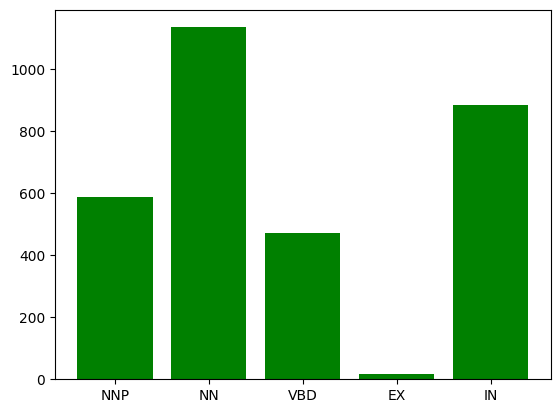

In [ ]:
plt.bar(keys[0:5], values[0:5], color = "green")


**The picture above is the result - a bar chart showing the 5 most frequent parts of speech.**

### Step 3 - Sentiment Analysis

In this part I will analyze the article in the sense of tone. Here it will displayed if the sentiment of the text is rather nagative, positive or neutral. By importing textblop package it will be possible to see the polarity of the text.

In [ ]:
from textblob import TextBlob

sentiment_counts = {"positive": 0, "negative": 0, "neutral": 0}
blob = TextBlob(article_text)

for sentence in blob.sentences:
    polarity = sentence.sentiment.polarity
    if polarity > 0:
        sentiment_counts["positive"] += 1
    elif polarity < 0:
        sentiment_counts["negative"] += 1
    else:
        sentiment_counts["neutral"] += 1

print(sentiment_counts)

{'positive': 154, 'negative': 70, 'neutral': 129}


Even though the text is trying to warn, question, and invite ethical inquiry into artificial intelligence, according to the for loop, the overall sentiment is rather positive, focusing on facts and information without pushing a specific agenda.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
labels = sentiment_counts.keys()
sizes = [value / sum(sentiment_counts.values()) * 100 for value in sentiment_counts.values()]
colors = ['green', 'red', 'grey']


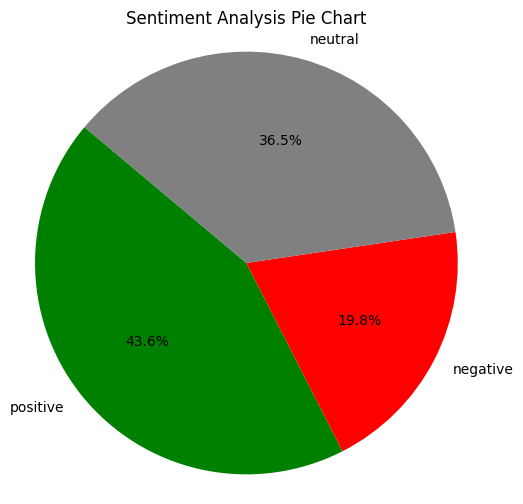

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Sentiment Analysis Pie Chart")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Step 4 - Frequency Analysis

I will start with removing all the stopwords, using the previously tokenized text from the article, to perform word frequency analysis.

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

filtered_text = [word for word in word_tokens if word.lower() not in stop_words and word.isalpha()]

#print(filtered_text)

Now, after filtering the text, I'll create a simple graph with the words that appear the most in the article.

In [ ]:
from nltk import FreqDist

fdist = FreqDist(filtered_text)

top_10 = fdist.most_common(10)
print(top_10)

[('Weizenbaum', 83), ('computer', 36), ('AI', 32), ('human', 28), ('would', 25), ('computers', 23), ('one', 23), ('Eliza', 20), ('time', 19), ('people', 18)]


In [ ]:
words = [word for word, count in top_10]
counts = [count for word, count in top_10]

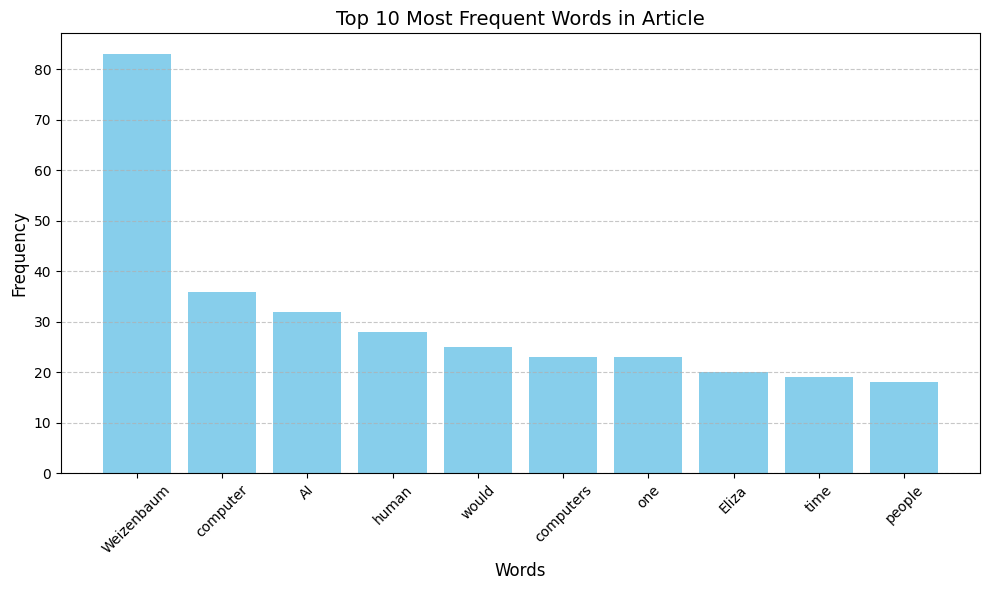

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(words, counts, color='skyblue')

plt.title("Top 10 Most Frequent Words in Article", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Step 5 - Conclusions

The diagram helps us with understanding how the article uses **a hybrid lexicon** — combining technical language (like AI, machine, program) with philosophical and social terms (people, human). This blend reflects the intersection between technology and human impact, characteristic of tech-ethics journalism.

In the top 10 words used in the article, one of the most frequent words is "would". By presenting such **modal verbs** the article might express uncertainty, possibility, and obligation — which aligns with the cautionary tone of the article.

Using TextBlob, the article displayed **slight positive polarity**.
This tone reflects a generally optimistic outlook, with a balanced mix of information and personal evaluation. While the article engages critically with the topic, it ultimately conveys a constructive perspective, highlighting the potential benefits of AI when responsibly developed.

To sum up, the article on Joseph Weizenbaum uses a strategically balanced vocabulary that fuses technical, ethical, and human-centered language. Linguistic features such as modal verbs, sentiment, and domain-specific collocations reinforce a thoughtful, cautious tone.